# Classic ML Pipeline for CSI Dataset

This notebook builds a full pipeline for `wifi_data_set_fixed`:
1. Read every `.data` file (each file is one data unit).
2. Build a 1D amplitude-over-time signal per unit and apply median filter with `median_width`.
3. Scale every unit using global min and max amplitude across the whole dataset.
4. Create an embedding with statistical and spectral features (including RSSI from raw data).
5. Run PCA and plot per-feature importance weighted by explained variance.

In [19]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Make project root importable so `tools` can be imported from notebooks/
project_root = Path.cwd()
if not (project_root / 'tools').exists() and (project_root.parent / 'tools').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.csi_parser import Parser
from tools.filters import median_filter

# Main parameters
dataset_root = project_root / 'wifi_data_set_fixed'
median_width = 5  # must be odd

if median_width % 2 == 0:
    raise ValueError('median_width must be odd')

np.random.seed(42)

In [20]:
def parse_path_meta(file_path: Path) -> dict:
    parts = file_path.parts
    return {
        'person_id': next((p for p in parts if p.startswith('id_person_')), 'unknown'),
        'label': next((p for p in parts if p.startswith('label_')), 'unknown'),
        'test_id': next((p for p in parts if p.startswith('test_')), 'unknown'),
    }


def skewness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 3))


def kurtosis_excess(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 4) - 3.0)


def spectral_features(signal: np.ndarray) -> tuple[float, float, float, float, float]:
    x = np.asarray(signal, dtype=np.float64)
    n = len(x)
    if n < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    spectrum = np.fft.rfft(x)
    power = np.abs(spectrum) ** 2
    freqs = np.fft.rfftfreq(n, d=1.0)

    power_sum = power.sum()
    if power_sum <= 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    centroid = float((freqs * power).sum() / power_sum)
    spread = float(np.sqrt(((freqs - centroid) ** 2 * power).sum() / power_sum))

    p_norm = power / power_sum
    eps = 1e-12
    entropy = float(-(p_norm * np.log2(p_norm + eps)).sum())

    dominant_idx = int(np.argmax(power))
    dominant_freq = float(freqs[dominant_idx])
    rolloff_threshold = 0.85 * power_sum
    rolloff = float(freqs[np.searchsorted(np.cumsum(power), rolloff_threshold)])

    return centroid, spread, entropy, dominant_freq, rolloff


def build_unit_signal(df: pd.DataFrame, window: int) -> np.ndarray:
    # For each packet, reduce subcarrier amplitudes to one value by averaging.
    amp_matrix = np.stack(df['amplitude'].to_numpy(), axis=0).astype(np.float64)
    raw_time_signal = amp_matrix.mean(axis=1)
    return median_filter(raw_time_signal, window)

In [21]:
from sklearn.model_selection import train_test_split

all_files = sorted(dataset_root.rglob('*.data'))
if not all_files:
    raise FileNotFoundError(f'No .data files found under {dataset_root}')

def get_test_group_dir(file_path: Path) -> Path:
    # Group key: .../id_person_xx/label_xx/test_xx
    for parent in file_path.parents:
        if parent.name.startswith('test_'):
            return parent
    raise ValueError(f'Could not find test_* folder in path: {file_path}')

file_to_group = {fp: get_test_group_dir(fp) for fp in all_files}
all_groups = sorted(set(file_to_group.values()))

group_labels = [parse_path_meta(group_path)['label'] for group_path in all_groups]
train_groups, test_groups = train_test_split(
    all_groups,
    test_size=0.2,
    random_state=42,
    stratify=group_labels,
    shuffle=True,
    )

train_group_set = set(train_groups)
test_group_set = set(test_groups)

train_files = [fp for fp in all_files if file_to_group[fp] in train_group_set]
test_files = [fp for fp in all_files if file_to_group[fp] in test_group_set]

# Safety check: no test_* folder is shared between train and test
shared_groups = train_group_set & test_group_set
if shared_groups:
    raise RuntimeError(f'Group leakage detected across split: {sorted(shared_groups)}')

def build_unit_cache(file_list: list[Path]) -> list[dict]:
    cache = []
    for file_path in file_list:
        df = Parser(file_path).parse()
        filtered_signal = build_unit_signal(df, median_width)
        cache.append({
            'file_path': file_path,
            'df': df,
            'filtered_signal': filtered_signal,
        })
    return cache

train_unit_cache = build_unit_cache(train_files)
test_unit_cache = build_unit_cache(test_files)

global_min = min(float(np.min(unit['filtered_signal'])) for unit in train_unit_cache)
global_max = max(float(np.max(unit['filtered_signal'])) for unit in train_unit_cache)

print(f'Total units (.data files): {len(all_files)}')
print(f'Total test_* groups: {len(all_groups)}')
print(f'Train groups: {len(train_groups)}')
print(f'Test groups: {len(test_groups)}')
print(f'Train units: {len(train_unit_cache)}')
print(f'Test units: {len(test_unit_cache)}')
print(f'Train-only global amplitude min: {global_min:.6f}')
print(f'Train-only global amplitude max: {global_max:.6f}')

Total units (.data files): 4800
Total test_* groups: 1600
Train groups: 1280
Test groups: 320
Train units: 3840
Test units: 960
Train-only global amplitude min: 0.691347
Train-only global amplitude max: 39.403599


In [22]:
def build_features_df(unit_cache: list[dict], global_min: float, global_max: float) -> pd.DataFrame:
    den = global_max - global_min
    if den <= 0:
        raise ValueError('Global max equals global min; cannot perform min-max scaling')

    rows = []
    for unit in unit_cache:
        file_path = unit['file_path']
        df = unit['df']
        signal = unit['filtered_signal']

        scaled_signal = (signal - global_min) / den
        scaled_signal = np.clip(scaled_signal, 0.0, 1.0)

        mean_val = float(np.mean(scaled_signal))
        std_val = float(np.std(scaled_signal))
        median_val = float(np.median(scaled_signal))
        min_val = float(np.min(scaled_signal))
        max_val = float(np.max(scaled_signal))
        q25 = float(np.percentile(scaled_signal, 25))
        q75 = float(np.percentile(scaled_signal, 75))
        iqr = q75 - q25
        range_val = max_val - min_val
        rms = float(np.sqrt(np.mean(scaled_signal ** 2)))
        energy = float(np.sum(scaled_signal ** 2))
        zcr = float(np.mean(np.abs(np.diff(np.signbit(scaled_signal - mean_val)).astype(np.int8))))

        sk = skewness(scaled_signal)
        kt = kurtosis_excess(scaled_signal)
        sc, ss, se, dom_freq, rolloff = spectral_features(scaled_signal)

        rssi_dbm = float(df['rssi_dbm'].median())

        meta = parse_path_meta(file_path)
        rows.append({
            'file_path': str(file_path),
            **meta,
            'n_packets': int(len(df)),
            'mean': mean_val,
            'std': std_val,
            'median': median_val,
            'skew': sk,
            'kurtosis': kt,
            'spectral_centroid': sc,
            'spectral_spread': ss,
            'spectral_entropy': se,
            'dominant_freq': dom_freq,
            'spectral_rolloff_85': rolloff,
            'min': min_val,
            'max': max_val,
            'q25': q25,
            'q75': q75,
            'iqr': iqr,
            'range': range_val,
            'rms': rms,
            'energy': energy,
            'zcr': zcr,
        })

    return pd.DataFrame(rows)

train_features_df = build_features_df(train_unit_cache, global_min, global_max)
test_features_df = build_features_df(test_unit_cache, global_min, global_max)
features_df = pd.concat([train_features_df, test_features_df], ignore_index=True)

print(f'Train features shape: {train_features_df.shape}')
print(f'Test features shape: {test_features_df.shape}')
features_df.head()

Train features shape: (3840, 24)
Test features shape: (960, 24)


,file_path,person_id,label,test_id,n_packets,mean,std,median,skew,kurtosis,...,spectral_rolloff_85,min,max,q25,q75,iqr,range,rms,energy,zcr
0,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.478846,0.034289,0.487212,-0.721638,-0.141173,...,0.0,0.393419,0.534750,0.458449,0.501095,0.042646,0.141330,0.480072,23.046940,0.101010
1,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.477401,0.043657,0.483232,-1.143821,2.515272,...,0.0,0.327005,0.563487,0.458711,0.503310,0.044600,0.236482,0.479393,22.981722,0.121212
2,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.030793,0.012979,0.031673,0.018646,-1.304995,...,0.0,0.010490,0.052684,0.017564,0.042101,0.024537,0.042194,0.033417,0.111666,0.111111
3,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_03,100,0.486473,0.040085,0.473711,0.354787,-0.759620,...,0.0,0.399718,0.571906,0.454974,0.518697,0.063723,0.172188,0.488122,23.826273,0.080808
4,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_03,100,0.422917,0.073487,0.409109,0.753098,0.260354,...,0.0,0.313770,0.654582,0.370788,0.473453,0.102664,0.340812,0.429254,18.425890,0.050505


In [23]:
feature_cols = [
    'mean', 'std', 'median', 'skew', 'kurtosis',
    'spectral_centroid', 'spectral_spread', 'spectral_entropy',
    'dominant_freq', 'spectral_rolloff_85',
    'min', 'max', 'q25', 'q75', 'iqr', 'range',
    'rms', 'energy', 'zcr'
]

X_train_raw = train_features_df[feature_cols].to_numpy(dtype=np.float64)
X_test_raw = test_features_df[feature_cols].to_numpy(dtype=np.float64)

# Save feature-wise min/max from train for stable inference preprocessing
feature_min = X_train_raw.min(axis=0)
feature_max = X_train_raw.max(axis=0)

# Clip train/test features to train-derived bounds
X_train = np.clip(X_train_raw, feature_min, feature_max)
X_test = np.clip(X_test_raw, feature_min, feature_max)

scaler_pca = StandardScaler()
X_train_std = scaler_pca.fit_transform(X_train)
X_test_std = scaler_pca.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

evr_df = pd.DataFrame({
    'PC': np.arange(1, len(evr) + 1),
    'EVR': evr,
    'CUM_EVR': cum_evr,
})

display(evr_df.head(10))

k_95 = int(np.searchsorted(cum_evr, 0.95) + 1)
print(f'Components for 95% variance: {k_95}')

# importance_j = sum_{k=1..K}((loading_{k,j}^2) * EVR_k), K = k_95
loadings = pca.components_[:k_95, :]
feature_importance = (loadings ** 2).T @ evr[:k_95]
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

X_train_pca_95 = X_train_pca[:, :k_95]
X_test_pca_95 = X_test_pca[:, :k_95]

y_train = (train_features_df['label'] != 'label_00').astype(int).to_numpy()
y_test = (test_features_df['label'] != 'label_00').astype(int).to_numpy()

print(f'X_train_pca_95 shape: {X_train_pca_95.shape}, y_train shape: {y_train.shape}')
print(f'X_test_pca_95 shape: {X_test_pca_95.shape}, y_test shape: {y_test.shape}')
print(f'Train class distribution: 0 -> {(y_train == 0).sum()}, 1 -> {(y_train == 1).sum()}')
print(f'Test class distribution: 0 -> {(y_test == 0).sum()}, 1 -> {(y_test == 1).sum()}')

print('Top 10 features by PCA-weighted importance (using first K components):')
display(importance_df.head(10))

,PC,EVR,CUM_EVR
0,1,0.593759,0.593759
1,2,0.139219,0.732978
2,3,0.067875,0.800853
3,4,0.062555,0.863408
4,5,0.052173,0.915582
5,6,0.039456,0.955038
6,7,0.024298,0.979336
7,8,0.007273,0.986609
8,9,0.006813,0.993422
9,10,0.003988,0.997410


Components for 95% variance: 6
X_train_pca_95 shape: (3840, 6), y_train shape: (3840,)
X_test_pca_95 shape: (960, 6), y_test shape: (960,)
Train class distribution: 0 -> 960, 1 -> 2880
Test class distribution: 0 -> 240, 1 -> 720
Top 10 features by PCA-weighted importance (using first K components):


,feature,importance
13,q75,0.055279
16,rms,0.055129
0,mean,0.055073
11,max,0.054966
2,median,0.054917
4,kurtosis,0.054847
9,spectral_rolloff_85,0.054801
12,q25,0.054348
18,zcr,0.053895
3,skew,0.053569


In [24]:
print(evr)

[5.93758941e-01 1.39218721e-01 6.78752066e-02 6.25554215e-02
 5.21734248e-02 3.94558416e-02 2.42982234e-02 7.27297436e-03
 6.81346395e-03 3.98817223e-03 1.02253428e-03 9.20338827e-04
 5.01189128e-04 1.19064056e-04 2.61981469e-05 2.85059647e-07
 6.00467101e-18 0.00000000e+00 0.00000000e+00]


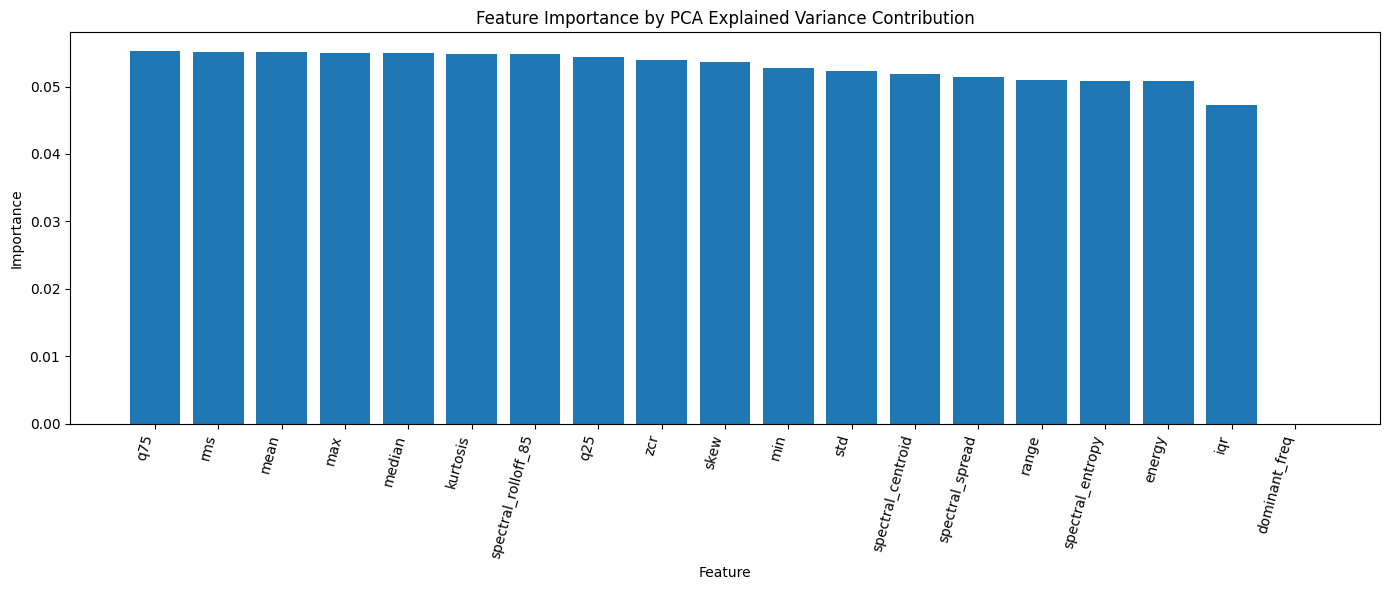

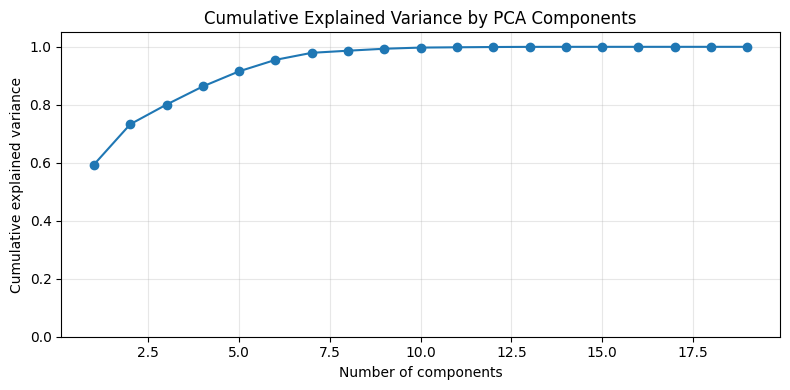

In [25]:
plt.figure(figsize=(14, 6))
plt.bar(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance by PCA Explained Variance Contribution')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
cum_evr = np.cumsum(evr)
plt.plot(np.arange(1, len(cum_evr) + 1), cum_evr, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Binary Classification on PCA (95% EVR)
Build binary labels from folder labels:
- class `0`: samples from `label_00`
- class `1`: all other labels

Train and tune models on PCA embeddings limited to components explaining 95% variance.

In [26]:
import sys
import subprocess

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Ensure CatBoost is available in the current notebook kernel
try:
    from catboost import CatBoostClassifier
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_cv_groups = [str(file_to_group[fp]) for fp in train_files]

model_spaces = {
    'CatBoost': (
        CatBoostClassifier(
            random_seed=42,
            loss_function='Logloss',
            verbose=False
        ),
        {
            'depth': [4, 6, 8],
            'learning_rate': [0.03, 0.1],
            'iterations': [200, 400],
            'l2_leaf_reg': [3, 5]
        }
    ),
    'LogReg': (
        LogisticRegression(max_iter=5000),
        {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs'],
            'penalty': ['l2']
        }
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'n_estimators': [300, 600],
            'max_depth': [None, 12, 24],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {
            'C': [0.5, 1.0, 5.0],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    ),
}

search_results = []
best_search = None

for model_name, (estimator, param_grid) in model_spaces.items():
    print(f'\nGrid search for: {model_name}')
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train_pca_95, y_train, groups=train_cv_groups)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_pca_95)

    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test_pca_95)[:, 1]
    else:
        # Fallback for models without predict_proba
        y_score = best_model.decision_function(X_test_pca_95)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)

    result = {
        'model': model_name,
        'best_cv_f1': search.best_score_,
        'test_f1': f1_score(y_test, y_pred),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'best_params': search.best_params_
    }
    search_results.append(result)

    if best_search is None or search.best_score_ > best_search.best_score_:
        best_search = search

results_df = pd.DataFrame(search_results).sort_values('best_cv_f1', ascending=False).reset_index(drop=True)
print('\nModel ranking by best CV F1:')
display(results_df[['model', 'best_cv_f1', 'test_f1', 'test_accuracy', 'test_roc_auc']])

best_model_name = results_df.loc[0, 'model']
best_model = best_search.best_estimator_
print(f'\nBest model: {best_model_name}')
print(f'Best CV F1: {best_search.best_score_:.4f}')
print(f'Best params: {best_search.best_params_}')

best_pred = best_model.predict(X_test_pca_95)
print('\nClassification report (best model on test set):')
print(classification_report(y_test, best_pred, digits=4))


Grid search for: CatBoost

Grid search for: LogReg


/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'pe


Grid search for: RandomForest

Grid search for: SVM

Model ranking by best CV F1:


,model,best_cv_f1,test_f1,test_accuracy,test_roc_auc
0,SVM,0.969123,0.975779,0.963542,0.984416
1,CatBoost,0.968076,0.974323,0.961458,0.987616
2,RandomForest,0.964870,0.970954,0.956250,0.983420
3,LogReg,0.892060,0.899194,0.843750,0.903021



Best model: SVM
Best CV F1: 0.9691
Best params: {'C': 5.0, 'gamma': 'auto', 'kernel': 'rbf'}

Classification report (best model on test set):
              precision    recall  f1-score   support

           0     0.9362    0.9167    0.9263       240
           1     0.9724    0.9792    0.9758       720

    accuracy                         0.9635       960
   macro avg     0.9543    0.9479    0.9510       960
weighted avg     0.9634    0.9635    0.9634       960



In [27]:
from pathlib import Path
import json
import joblib

artifacts_dir = project_root / 'artifacts' / 'classic_ml'
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_type = 'catboost' if best_model_name == 'CatBoost' else 'sklearn'
if model_type == 'catboost':
    model_path = artifacts_dir / 'catboost_model.cbm'
    best_model.save_model(str(model_path))
else:
    model_slug = best_model_name.lower().replace(' ', '_')
    model_path = artifacts_dir / f'{model_slug}_model.joblib'
    joblib.dump(best_model, model_path)

preproc_path = artifacts_dir / 'preprocessing.joblib'
meta_path = artifacts_dir / 'metadata.json'

# Save preprocessing artifacts required for inference
preproc_bundle = {
    'median_width': median_width,
    'global_min': float(global_min),
    'global_max': float(global_max),
    'feature_cols': feature_cols,
    'feature_min': feature_min,
    'feature_max': feature_max,
    'scaler_pca': scaler_pca,
    'pca': pca,
    'k_95': int(k_95),
    'model_type': model_type,
}
joblib.dump(preproc_bundle, preproc_path)

meta = {
    'best_model_name': best_model_name,
    'model_type': model_type,
    'best_cv_f1': float(best_search.best_score_),
    'best_params': best_search.best_params_,
    'model_path': str(model_path),
    'preprocessing_path': str(preproc_path),
    'class_mapping': {
        '0': 'label_00',
        '1': 'label_01 | label_02 | label_03',
    },
    'preprocessing_notes': {
        'feature_clip': 'Inference clips each feature to [feature_min, feature_max] from train before StandardScaler+PCA',
    },
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

print(f'Best model name: {best_model_name}')
print(f'Model type: {model_type}')
print(f'Saved model: {model_path}')
print(f'Saved preprocessing: {preproc_path}')
print(f'Saved metadata: {meta_path}')

Best model name: SVM
Model type: sklearn
Saved model: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/svm_model.joblib
Saved preprocessing: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/preprocessing.joblib
Saved metadata: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/metadata.json
